# Практична робота 3.3
## Аналіз набору даних з Kaggle

**Мета роботи:** навчитися завантажувати, обробляти, очищати та аналізувати
реальні набори даних з платформи Kaggle.

### 1. Пошук набору даних на Kaggle

На сайті [Kaggle](https://www.kaggle.com/) обрано набір даних із категорії
**бізнес** — «Diamonds»: характеристики та ціни майже 54 тисяч діамантів.

Набір підходить для цієї роботи, бо містить одночасно:

- **числові змінні** — вага в каратах, ціна, глибина, ширина майданчика,
  три лінійні розміри;
- **категоріальні змінні** — якість огранки, колір, чистота.

Опис стовпців:

| Стовпець | Опис |
|---|---|
| `carat` | вага діаманта в каратах |
| `cut` | якість огранки: Fair, Good, Very Good, Premium, Ideal |
| `color` | колір від J (найгірший) до D (найкращий) |
| `clarity` | чистота від I1 (найгірша) до IF (найкраща) |
| `depth` | відносна глибина, % |
| `table` | ширина верхнього майданчика, % |
| `price` | ціна в доларах США |
| `x`, `y`, `z` | довжина, ширина, висота в мм |

### 2. Завантаження даних

Набір завантажено з Kaggle у форматі CSV — файл `diamonds.csv`
(53 940 записів, 10 стовпців). Файл лежить у папці `data` поруч із ноутбуком.

### 3. Завантаження та перегляд даних у Python

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('../data/diamonds.csv')

# Перегляд перших рядків
print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [2]:
# Огляд інформації про набір даних
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
None


In [3]:
print('Рядків:  ', df.shape[0])
print('Стовпців:', df.shape[1])
print()
print('Назви стовпців:')
print(list(df.columns))

Рядків:   53940
Стовпців: 10

Назви стовпців:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


### 4. Очищення даних

In [4]:
# Перевірка на пропущені значення
print(df.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [5]:
# Явних пропусків немає, але серед розмірів є нулі.
# Діамант не може мати нульову довжину чи висоту - це насправді пропущені виміри.
print('Рядків із нульовим розміром:', ((df[['x', 'y', 'z']] == 0).any(axis=1)).sum())
print()
print(df[(df[['x', 'y', 'z']] == 0).any(axis=1)].head())

Рядків із нульовим розміром: 20

       carat      cut color clarity  depth  table  price     x     y    z
2207    1.00  Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01  Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10  Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01  Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50     Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0


In [6]:
# Замінюємо нулі на NaN, щоб Pandas бачив їх як пропуски
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

print(df[['x', 'y', 'z']].isnull().sum())

x     8
y     7
z    20
dtype: int64


In [7]:
# Заповнюємо пропуски медіаною
# (медіана, а не середнє, бо в розмірах є великі викиди)
df['x'] = df['x'].fillna(df['x'].median())
df['y'] = df['y'].fillna(df['y'].median())
df['z'] = df['z'].fillna(df['z'].median())

print('Пропущених значень залишилось:', df.isnull().sum().sum())

Пропущених значень залишилось: 0


In [8]:
# Видалення дублікатів
print('Рядків до видалення дублікатів:', len(df))
df = df.drop_duplicates().reset_index(drop=True)
print('Рядків після видалення:       ', len(df))

Рядків до видалення дублікатів: 53940
Рядків після видалення:        53794


In [9]:
# Перетворення категоріальних змінних на числові.
# Усі три категорії впорядковані, тому задаємо порядок явно,
# щоб більший код означав кращу якість.
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut_code'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True).codes
df['color_code'] = pd.Categorical(df['color'], categories=color_order, ordered=True).codes
df['clarity_code'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True).codes

print(df[['cut', 'cut_code', 'color', 'color_code', 'clarity', 'clarity_code']].head(10))

         cut  cut_code color  color_code clarity  clarity_code
0      Ideal         4     E           5     SI2             1
1    Premium         3     E           5     SI1             2
2       Good         1     E           5     VS1             4
3    Premium         3     I           1     VS2             3
4       Good         1     J           0     SI2             1
5  Very Good         2     J           0    VVS2             5
6  Very Good         2     I           1    VVS1             6
7  Very Good         2     H           2     SI1             2
8       Fair         0     E           5     VS2             3
9  Very Good         2     H           2     VS1             4


### 5. Описова статистика

In [10]:
# Описова статистика для числових змінних
numeric = df[['carat', 'price', 'depth', 'table', 'x', 'y', 'z']]
print(numeric.describe().round(2))

          carat     price     depth     table         x         y         z
count  53794.00  53794.00  53794.00  53794.00  53794.00  53794.00  53794.00
mean       0.80   3933.07     61.75     57.46      5.73      5.74      3.54
std        0.47   3988.11      1.43      2.23      1.12      1.14      0.70
min        0.20    326.00     43.00     43.00      3.73      3.68      1.07
25%        0.40    951.00     61.00     56.00      4.71      4.72      2.91
50%        0.70   2401.00     61.80     57.00      5.70      5.71      3.53
75%        1.04   5326.75     62.50     59.00      6.54      6.54      4.03
max        5.01  18823.00     79.00     95.00     10.74     58.90     31.80


In [11]:
# Основні показники окремо
print('Середнє значення:')
print(numeric.mean().round(2))
print()
print('Медіана:')
print(numeric.median().round(2))
print()
print('Стандартне відхилення:')
print(numeric.std().round(2))

Середнє значення:


carat       0.80
price    3933.07
depth      61.75
table      57.46
x           5.73
y           5.74
z           3.54
dtype: float64

Медіана:
carat       0.70
price    2401.00
depth      61.80
table      57.00
x           5.70
y           5.71
z           3.53
dtype: float64

Стандартне відхилення:
carat       0.47
price    3988.11
depth       1.43
table       2.23
x           1.12
y           1.14
z           0.70
dtype: float64


In [12]:
# Скільки діамантів кожної якості огранки
print(df['cut'].value_counts())
print()
print('Медіанна ціна за якістю огранки:')
print(df.groupby('cut')['price'].median().round(0))

cut
Ideal        21488
Premium      13748
Very Good    12069
Good          4891
Fair          1598
Name: count, dtype: int64

Медіанна ціна за якістю огранки:


cut
Fair         3282.0
Good         3042.0
Ideal        1813.0
Premium      3182.0
Very Good    2647.0
Name: price, dtype: float64


### 6. Візуалізація даних

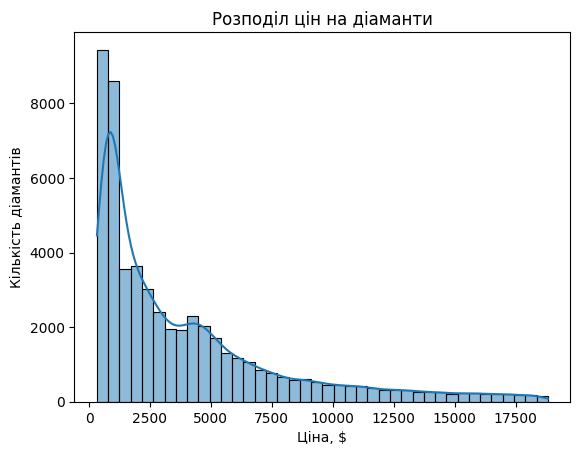

In [13]:
# Гістограма: розподіл цін
sns.histplot(df['price'], bins=40, kde=True)
plt.title('Розподіл цін на діаманти')
plt.xlabel('Ціна, $')
plt.ylabel('Кількість діамантів')
plt.show()

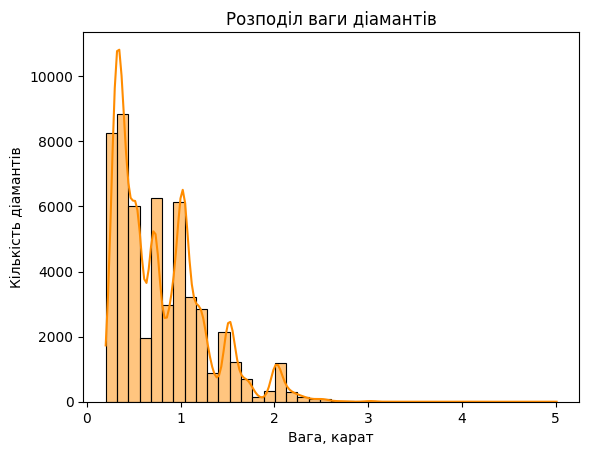

In [14]:
# Гістограма: розподіл ваги
sns.histplot(df['carat'], bins=40, kde=True, color='darkorange')
plt.title('Розподіл ваги діамантів')
plt.xlabel('Вага, карат')
plt.ylabel('Кількість діамантів')
plt.show()

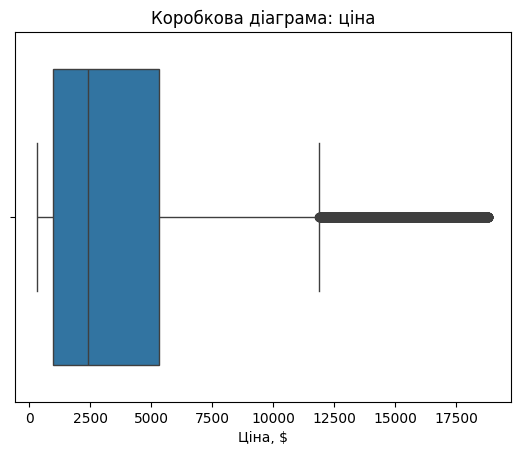

In [15]:
# Коробкова діаграма: аналіз викидів за ціною
sns.boxplot(x=df['price'])
plt.title('Коробкова діаграма: ціна')
plt.xlabel('Ціна, $')
plt.show()

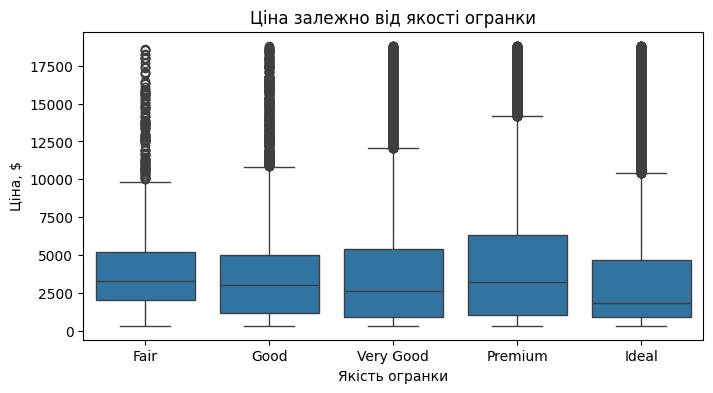

In [16]:
# Коробкова діаграма цін за якістю огранки
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['cut'], y=df['price'], order=cut_order)
plt.title('Ціна залежно від якості огранки')
plt.xlabel('Якість огранки')
plt.ylabel('Ціна, $')
plt.show()

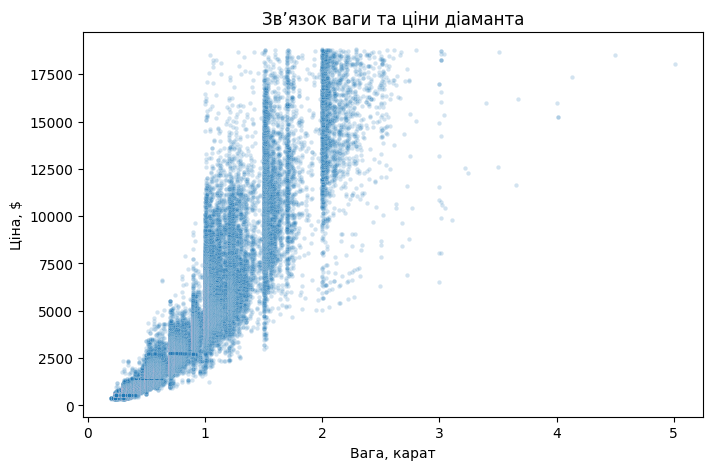

In [17]:
# Діаграма розсіювання: вага та ціна
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['carat'], y=df['price'], alpha=0.2, s=10)
plt.title('Звʼязок ваги та ціни діаманта')
plt.xlabel('Вага, карат')
plt.ylabel('Ціна, $')
plt.show()

### 7. Кореляційний аналіз

In [18]:
# Кореляційна матриця для кількісних змінних
cols = ['carat', 'price', 'depth', 'table', 'x', 'y', 'z',
        'cut_code', 'color_code', 'clarity_code']
correlation_matrix = df[cols].corr()

print(correlation_matrix['price'].round(3))

carat           0.922
price           1.000
depth          -0.011
table           0.127
x               0.887
y               0.867
z               0.867
cut_code       -0.052
color_code     -0.172
clarity_code   -0.146
Name: price, dtype: float64


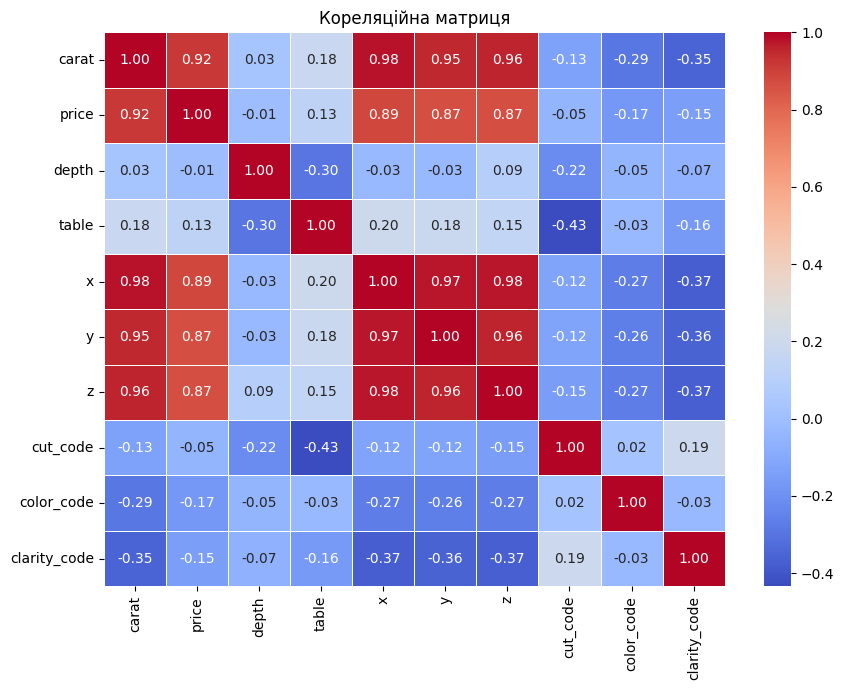

In [19]:
# Візуалізація кореляційної матриці
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

### 8. Звітування. Висновки

**Опис набору даних.** Використано набір «Diamonds» з Kaggle — 53 940 записів
про продані діаманти. Кожен запис містить вагу в каратах, три оцінки якості
(огранка, колір, чистота), геометричні розміри та ціну в доларах.

**Очищення даних.** Функція `isnull()` показала нуль пропусків, але це не означає,
що дані чисті. У 20 записах довжина, ширина або висота дорівнюють нулю —
фізично неможливе значення, тобто насправді це пропущений вимір, записаний нулем.
Такі нулі замінено на `NaN` і заповнено медіаною: саме медіаною, а не середнім,
бо серед розмірів є явні викиди (максимальна ширина 58.9 мм проти типових 5.7 мм).
Також видалено 146 повних дублікатів. Після очищення залишилось 53 794 записи.

Усі три категоріальні змінні впорядковані (огранка від Fair до Ideal,
колір від J до D, чистота від I1 до IF), тому їх закодовано з явним
зазначенням порядку, щоб більший код означав кращу якість.

**Описова статистика.**

| Змінна | Середнє | Медіана | Ст. відхилення | Максимум |
|---|---|---|---|---|
| Ціна, $ | 3 933 | 2 401 | 3 988 | 18 823 |
| Вага, карат | 0.80 | 0.70 | 0.47 | 5.01 |
| Глибина, % | 61.75 | 61.80 | 1.43 | 79.00 |

Ціна та вага мають помітну правосторонню асиметрію: середня ціна (3 933 $)
у півтора рази більша за медіанну (2 401 $), бо невелика кількість дуже дорогих
каменів тягне середнє вгору. Натомість `depth` розподілена майже симетрично —
середнє і медіана збігаються, а стандартне відхилення мале: це технологічний
параметр, який майстри витримують у вузькому діапазоні.

**Візуалізація.** Гістограма цін показує, що більшість діамантів коштують
до 5 000 $, а розподіл має довгий правий хвіст. На гістограмі ваги видно
характерні піки біля «круглих» значень — 0.3, 0.5, 0.7, 1.0 карата:
камені навмисно шліфують так, щоб не перетнути психологічну межу вниз.
Діаграма розсіювання показує чіткий, але **нелінійний** звʼязок ваги та ціни —
крива, що загинається вгору: подвоєння ваги дорожчає камінь більш ніж удвічі.

Найцікавіший результат дала коробкова діаграма цін за якістю огранки:
діаманти найкращої огранки **Ideal мають найнижчу медіанну ціну (1 813 $)**,
а найгіршої Fair — одну з найвищих (3 282 $). Це не помилка: ідеальну огранку
частіше роблять на дрібних каменях, де вона економічно виправдана, тож вирішує
не огранка, а вага.

**Кореляційний аналіз.** Кореляції з ціною:

- `carat` — **0.92**, найсильніший зв'язок у наборі;
- `x`, `y`, `z` — 0.89, 0.87, 0.87; це фактично та сама вага, виражена
  через розміри, тому окремої інформації вони майже не додають;
- `table` — 0.13, `depth` — -0.01: форма огранки на ціну майже не впливає;
- `color_code` — -0.17, `clarity_code` — -0.15: зв'язок слабкий і від'ємний,
  що виглядає парадоксально, але пояснюється тим самим ефектом, що й з огранкою:
  кращі за кольором і чистотою камені здебільшого дрібніші.

**Загальний висновок.** Ціну діаманта визначає передусім вага — вона пояснює
майже весь розкид. Оцінки якості (огранка, колір, чистота) самі по собі
корелюють із ціною слабко й навіть від'ємно, бо переплітаються з вагою:
щоб оцінити їхній справжній внесок, треба порівнювати камені однакової ваги.
Це класичний приклад того, що коефіцієнт кореляції показує лише прямий
лінійний зв'язок і його не можна читати як причинність.